<a href="https://colab.research.google.com/github/dlhegend/-TS_Academy_Capstone_Project/blob/restore-main/notebook/AreolaDeborah_TSA_CapstoneProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview of the Dataset
##Major Indices in the Nigeria Capital Markets.

This dataset contains historical data on stock market indices in Nigeria.

An index in this context represents a measure of the performance of a group of stocks listed on the the Nigerian Exchange group(NGX), From 2012-2023

Each row in this dataset typically includes:

Date- Which is the trading day,month and year.The day the value was recorded

Index Price or Value- The index value represents the combined performance of the listed companies included in the index on that specific date. it is the value that calculates or summarizes the companies overall performance

Index Name - The index are the market indicator, These indicator are the measurement tool that shows the performance of the market.The market indicators we have in this dataset are NGX ASI, S&P/FMDQ SBI, AFEX ACI, USD/NGN.

1. NGX ASI: The Nigerian Exchange Group All-Share Index (NGX ASI) measures the overall performance of companies listed on the Nigerian stock market.

2. S&P/FMDQ SBI: The S&P/FMDQ index is associated with FMDQ Group, and it tracks performance in the fixed-income (bond) market.

3. AFEX ACI : The AFEX Commodity Index (ACI) is related to AFEX Commodities Exchange.

This index measures the performance of commodity markets (such as agricultural products).

4. The USD/NGN represents the exchange rate between the US Dollar and the Nigerian Naira.

We would be using the NGX ASI as our sole indicator for Time Series Analysis.







In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

This is what our Top 5 dataset look like

In [26]:
df = pd.read_csv('/content/NGX_ASI_Index_Price_Data (1).csv')
df.head()

,date,avr_monthly_kiloprice
0,2012-Jan,20.80
1,2012-Feb,20.52
2,2012-Mar,20.92
3,2012-Apr,21.27
4,2012-May,22.41


In [27]:
#The dataset has 137 rows and two columns

df.shape

(137, 2)

df.describe help us to see how the data point is close and far from each other, in this dataset the mean is far from the standard deviation, the maximum and the minimum datapoint are far apart, from this information we could tell that the dataset is skewed.

In [28]:
df.describe()

,avr_monthly_kiloprice
count,137.000000
mean,34.301241
std,8.428547
min,20.520000
25%,27.430000
50%,33.350000
75%,39.270000
max,55.080000


visualizing the Average Monthly share index price we could tell that the dataset is slightly tilted towards the right. The distribution is mostly clustered around the average index price 25 and 40. As the index price increases around 40, there is a decrease in the freequency of the average monthly price index. This could arise as a result of economic factor or poor earnings

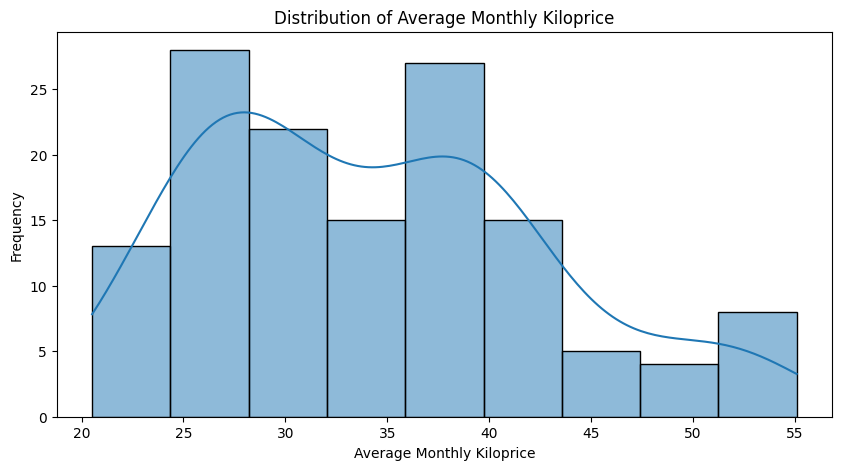

In [29]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(df['avr_monthly_kiloprice'], kde=True)
plt.title("Distribution of Average Monthly Kiloprice")
plt.xlabel("Average Monthly Kiloprice")
plt.ylabel("Frequency")
plt.show()

Looking at the datatype of the Month column, we could see that the datatype is an object, as we know that machine learning model doesn't recognise an object in machine so as Time Series Model,therefore there is a need for us to convert it to integer by encoding. This rule is applicable to time series analysis,in time series analysis we usually convert
the date column to DATETIME DATATYPE, by so doing we're telling python to recognise the column as DATE not text or string.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   137 non-null    object 
 1   avr_monthly_kiloprice  137 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.3+ KB


## Convering The Date Column Into DATETIME And Set As Index

In [31]:
"""this code change the month column to datetime column df in an order form and also set the date column as index
in an order form"""

df['date']=pd.to_datetime(df['date'])
df.set_index('date',inplace=True)
df.head()

,avr_monthly_kiloprice
date,
2012-01-01,20.80
2012-02-01,20.52
2012-03-01,20.92
2012-04-01,21.27
2012-05-01,22.41


In [32]:
'''After using the DATETIME DATATYPE, we decided to check our Info again, and we could see that,  we now have only  one feature
which is avg_monthly_price and the Time Stamp in index form'''

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 137 entries, 2012-01-01 to 2023-05-01
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   avr_monthly_kiloprice  137 non-null    float64
dtypes: float64(1)
memory usage: 2.1 KB


##Graphical Analysis of the Market Index

The line graph presents the movement of the average monthly share price of the market index from 2012 to 2023. The horizontal axis represents time (Date), while the vertical axis represents the average monthly price.

From the graph, it can be observed that the index does not move in a straight line but fluctuates over the period. There are noticeable periods of increase and decrease, showing that the market experienced both growth and decline at different times.

At the beginning of the period (around 2012), the index value is relatively low. It rises steadily until around 2014, after which a decline is observed between 2014 and 2016. The index then recovers and increases again around 2017–2018 before experiencing another decline between 2018 and 2020.

A sharp drop is visible around 2020, followed by a strong upward movement from 2021 to 2023. By the end of the period, the index reaches its highest level, indicating significant growth compared to earlier years.

Overall, the graph shows that the market index exhibits fluctuations over time with an overall upward movement across the study period. This suggests that although the market experienced periods of instability, it demonstrated long-term growth



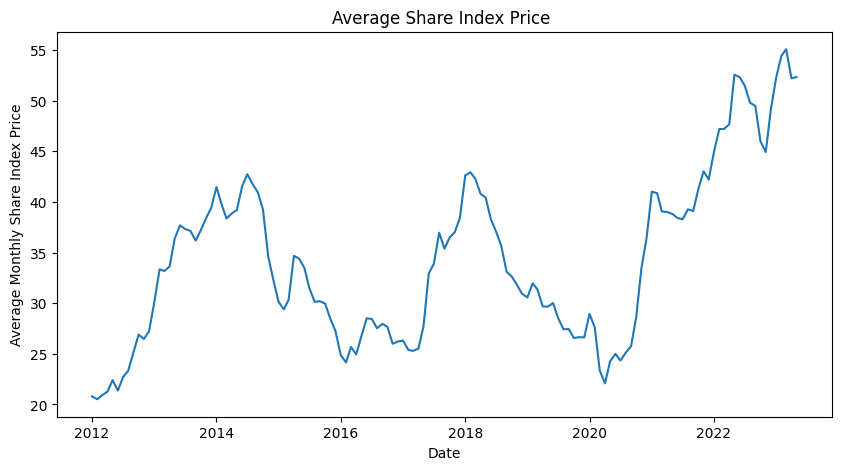

In [33]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['avr_monthly_kiloprice'])
plt.title("Average Share Index Price ")
plt.xlabel("Date")
plt.ylabel("Average Monthly Share Index Price")
plt.show()

##Trend in Average Monthly Share Index Price


The chart shows the movement of the Average Monthly Share Index Price from 2012 to 2023 using two lines: the original monthly values (blue) and a 12-month moving average trend (green).

Overall, the market experienced cyclical movements periods of growth followed by declines and recovery. The index rose strongly between 2012 and 2014, declined around 2015–2016, recovered in 2017–2018, dropped again around 2019–2020, and then recorded significant and sustained growth from 2021 to 2023.

The moving average line highlights the long-term trend by smoothing out short-term fluctuations. Despite temporary downturns, the overall direction of the index shows long-term growth, with a strong upward momentum in the most recent years.

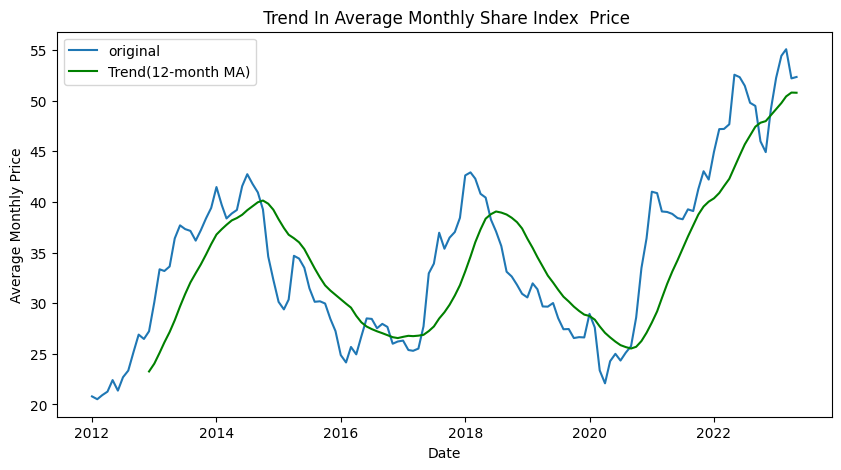

In [34]:
df['Trend']=df['avr_monthly_kiloprice'].rolling(window=12).mean()

plt.figure(figsize=(10,5))
plt.plot(df["avr_monthly_kiloprice"],label="original")
plt.plot(df["Trend"],label="Trend(12-month MA)",color="green")
plt.title(" Trend In Average Monthly Share Index  Price")
plt.xlabel("Date")
plt.ylabel("Average Monthly Price")
plt.legend()
plt.show()


##DECOMPOSITION
There is a need to understand what is going on beneath the dataset, to do so evaluating the component of the dataset is essential.How then can we do this? that is what we refer to as DECOMPOSITION.

Decomposition is the graphical representation of the component in every time series dataset, by seperating them in patterns. A time series is usually broken into 3 main components.

1 Trend: This shows the long-term direction of the data. It is either increasing generally, decreasing or staying constant.

2 Seasonality: This shows repeating patterns over fixed periods (daily, monthly, quarterly, yearly).

3 Residual / Noise: This is otherwise know as the white noise.This is the random fluctuation left after removing trend and seasonality.

The plot below shows the graphical representation of the component in this dataset, and we would be able to see the trend, the seasonality and the residual,all of these displayed together.

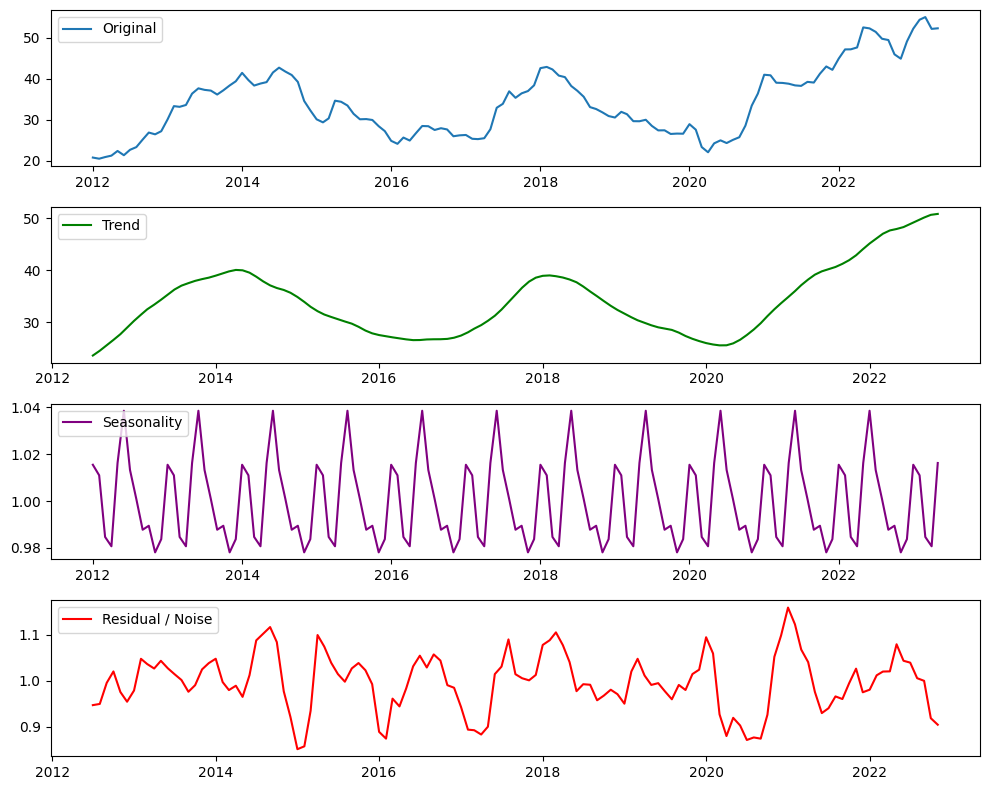

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['avr_monthly_kiloprice'], model='multiplicative', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.plot(df['avr_monthly_kiloprice'], label='Original')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Trend', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonality', color='purple')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual / Noise', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

The trend and the seasonality shown in this data means our dataset is not stational.A dataset is said to be stational when it is stable overtime, that means we want something that is not going upward or downward movement,we want something that is stationed or revolve around the mean  and not a plot that shows a clear upward or downward trend. Therefore to ascertain that the dataset is not stational, we would be adopting a test for stationarity.

## In time series analysis, a test for stationarity is a statistical method used to determine whether a time series data is stationary or non-stationary.

Augmented Dickey-Fuller (ADF) Test is the most common test used. It helps to check if the time series has a unit root (a mathematical way of saying "non-stationary"), Also It gives you a p-value (a number between 0 and 1)

interpretation:

p-value < 0.05 → Data is stationary (reject the trend)

p-value ≥ 0.05 → Data is non-stationary (has a trend)

In [36]:
from statsmodels.tsa.stattools import adfuller

result=adfuller(df['avr_monthly_kiloprice'])
print('ADF Statistics:',result[0])
print('p_value:', result[1])
if result[1] < 0.05:
  print('The data is stationary')
else:
  print('The data is non_sationary')


ADF Statistics: -1.6879689803233129
p_value: 0.4373216371351407
The data is non_sationary


We were able to ascertain that the data is non-stationary.There is a need to transform the data so its behavior becomes stable over time. To do this, we have two methods.

1. Differencing: This calculates the difference between consecutive observations.Instead of looking at the actual value, we look at how much it changes from one time step to the next.

2. Detrending: Detrending means removing the long-term trend component from a time series.

We would use one(1) out of this two method,which is Differencing.

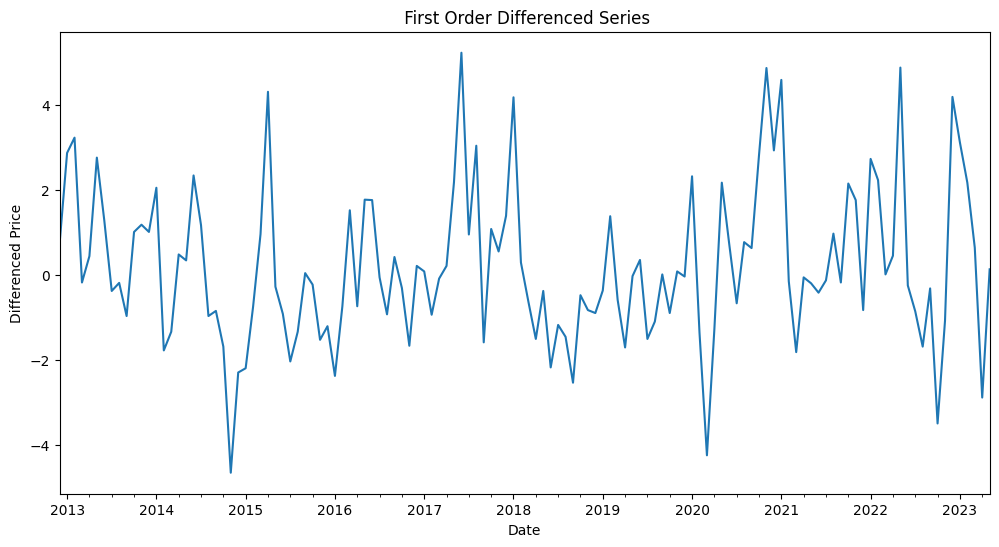

In [38]:
df['Diff']=df['avr_monthly_kiloprice'] - df['avr_monthly_kiloprice'].shift(1)

df_Diff = df.dropna()
plt.figure(figsize=(12, 6))
df_Diff['Diff'].plot(title=" First Order Differenced Series")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.show()

##After differencing,we need to check if the data is stationary.

In [40]:
result_diff = adfuller(df_Diff['Diff'])
print('ADF Statistics:', result_diff[0])
print('p_value:', result_diff[1])
if result_diff[1] < 0.05:
  print('The data is stationary')
else:
  print('The data is non_sationary')

ADF Statistics: -7.340664548261752
p_value: 1.0673265584561704e-10
The data is stationary


##Now that out data is stationary, we then introduce the Arima Model, Arima Model only works when data is stationary.


ARIMA: is a time-series forecasting method that learns from the past to predict the future. Before fitting ARIMA, we need to decide how many past values and past errors to include, this is where we implement the Autocorrelation(ACF) and the Partial Autocorrelation(PACF)

AUTOCORRELATION(ACF):This shows how todays value is related to past value. If past values are similar, they can help predict todays value

PARTIAL AUTOCORRELATION(PACF):This shows how todays value is related to specific value,ignoring the influence of the value in between.

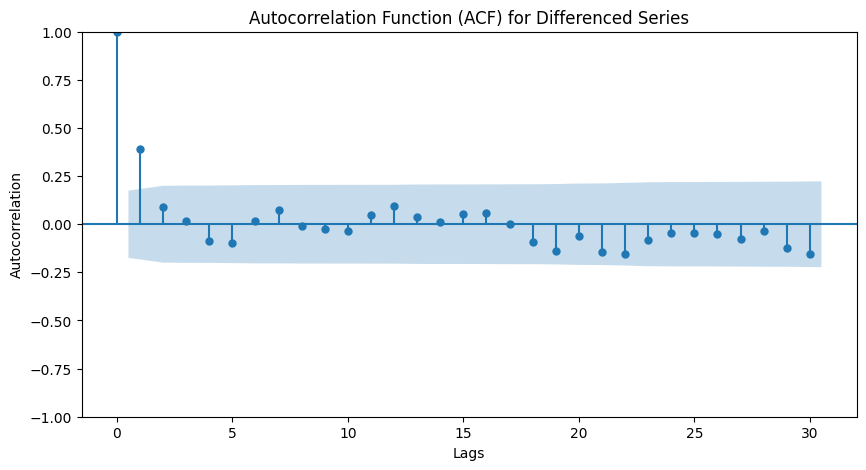

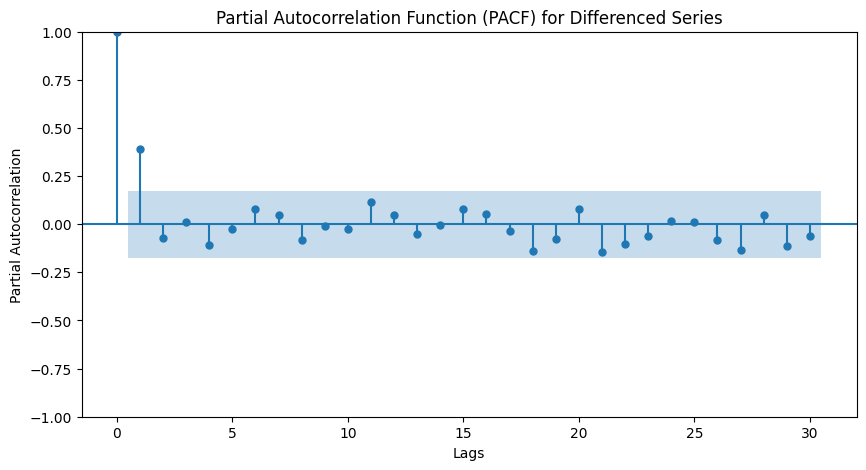

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF
plt.figure(figsize=(10, 5))
plot_acf(df_Diff['Diff'], lags=30,ax=plt.gca())
plt.title('Autocorrelation Function (ACF) for Differenced Series')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

# Plot PACF
plt.figure(figsize=(10, 5))
plot_pacf(df_Diff['Diff'], lags=30, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) for Differenced Series')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

##Splitting The DataSet To Train And Test

Splitting in time series means dividing your dataset into training and testing sets but without shuffling the data. Unlike normal machine learning, time series data must respect time order,Otherwise the model could see a future month while trying to predict an earlier month, giving unrealistically good results.

In [63]:
train_size = int(len(df) * 0.8)

train = df['avr_monthly_kiloprice'][:train_size]
test = df['avr_monthly_kiloprice'][train_size:]

In [65]:
train.tail()

,avr_monthly_kiloprice
date,
2020-09-01,25.76
2020-10-01,28.59
2020-11-01,33.47
2020-12-01,36.41
2021-01-01,41.01


In [67]:
test.head()

,avr_monthly_kiloprice
date,
2021-02-01,40.87
2021-03-01,39.06
2021-04-01,39.01
2021-05-01,38.82
2021-06-01,38.41


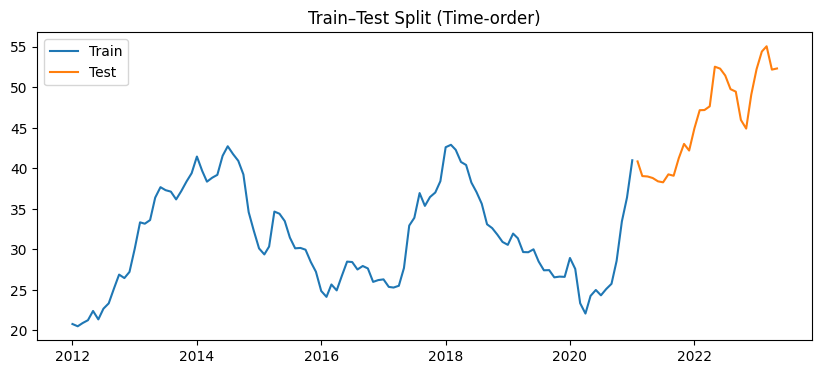

In [64]:
#Visualization of Train-test Split
plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.legend()
plt.title("Train–Test Split (Time-order)")
plt.show()

##We then fit ARIMA Model in the train dataset in this order parameter (p,d,q)

##P: Autoregressive order (AR)

p represents the number of lagged values of the series used to predict the current value. That is, How many past values do we look at?”

When:

p = 1 → today depends on yesterday

p = 2 → today depends on last two days

This is about memory in the series and PACF plot usually helps determine p.

##D:  Degree of differencing

d represents the number of times the series is differenced to make it stationary

##Q:  Moving Average order (MA), It's answer the questtion, How many past errors do we use?”

q represents the number of lagged forecast errors used in the model.

This means the model uses past prediction errors to improve future predictions, it's helps correct past mistakes. ACF plot usually helps determine q.


##In this dataset the p=1, d=1 , q=1





In [71]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1, 1, 1)) # Using the best order found (p=1, d=1, q=1)
fitted_model = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


##After fitting ARIMA model we then Forecast for the test period

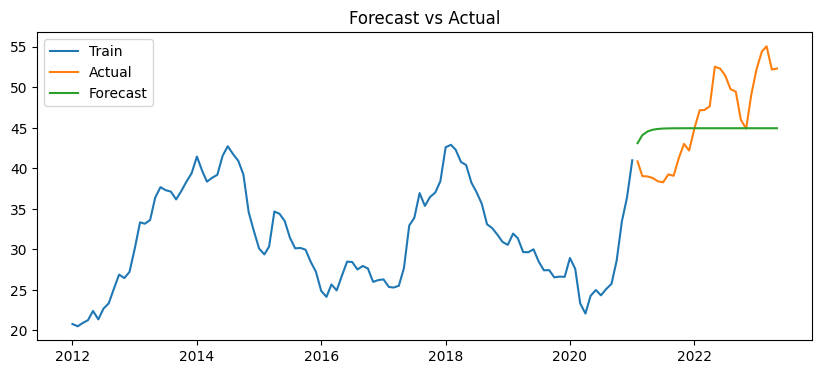

In [72]:
forecast_1 = fitted_model.forecast(steps=len(test))

plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast_1, label='Forecast')
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

#The graphical representation above indicate that ARIMA model is insufficient for the dataset.

#Why this indicates model failure.

In Time Series Analysis, a good forecasting model should produce predictions that closely follow the pattern of the actual data. In this case:

The forecast does not capture the upward trend.

It fails to follow the fluctuations in the test data.

The difference between the forecast and the actual values widens over time.

This widening gap is the clear evidence of deviation, showing that the ARIMA model did not adequately model the data, which is why a Seasonal ARIMA (SARIMA) model is more appropriate for capturing the seasonal behavior.To address this limitation, a Seasonal ARIMA (SARIMA) model will be adopted, as it extends the ARIMA framework by incorporating seasonal parameters that allow the model to capture both non-seasonal and seasonal dynamics in the data.

##SARIMA

In Time Series Analysis, the Seasonal ARIMA (SARIMA) model is an extension of the ARIMA model that is used when a time series dataset contains seasonal patterns.

While ARIMA models only capture trend and short-term dependencies, SARIMA is designed to model both non-seasonal and seasonal behavior in the data.

 SARIMA adds four parameters:(P,D,Q,S)

The 'S' is the length of the seasonal cycle (e.g., 12 for monthly data with yearly seasonality)

In [73]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, order=(1, 1, 1),
  seasonal_order = (1,1,1,12)
)
results = model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


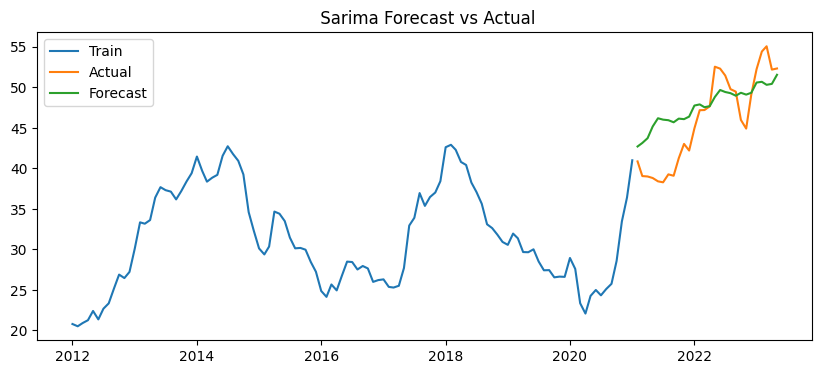

In [76]:
forecast_2 = results.forecast(steps=len(test))

plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast_2, label='Forecast')
plt.legend()
plt.title(" Sarima Forecast vs Actual")
plt.show()


##Performance of the SARIMA Model

From the forecast graph, the SARIMA model demonstrates improved performance compared to the ARIMA model. The forecasted values follow the general upward movement of the actual observations in the test period. Unlike the ARIMA forecast, which produced an almost constant line, the SARIMA forecast shows gradual variation and moves closer to the actual values.

This indicates that the SARIMA model successfully captures part of the seasonal structure and overall trend present in the data.The model provides a more accurate representation of the data and improves forecasting performance.

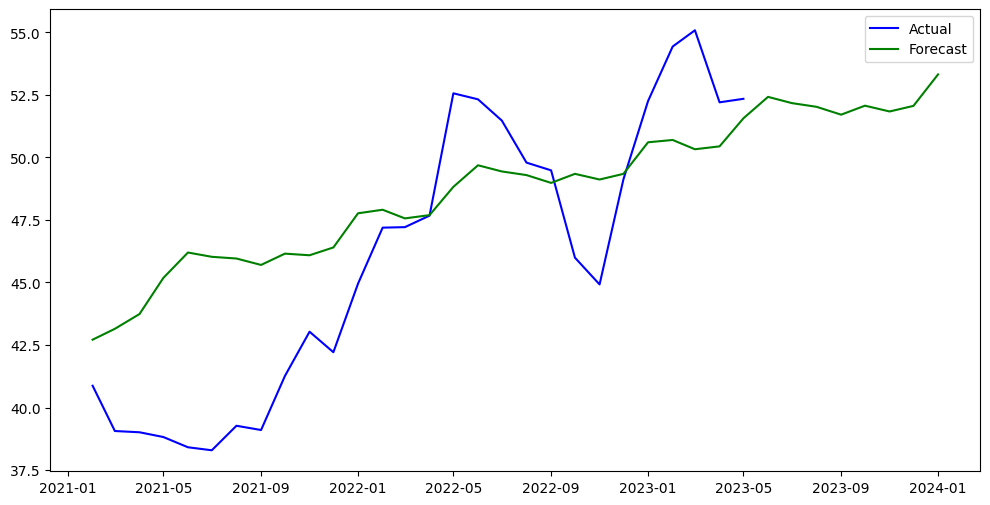

In [81]:
forecast = results.get_forecast(steps=36)

plt.figure(figsize=(12, 6))
plt.plot(test, label='Actual',color='blue')
plt.plot(forecast.predicted_mean, label='Forecast', color='green')
plt.legend()
plt.show()

- **Mean Absolute Error (MAE):** This metric measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

- **Root Mean Squared Error (RMSE):** This metric represents the standard deviation of the residuals (prediction errors). It measures the average magnitude of the errors. Since the errors are squared before they are averaged, the RMSE gives a relatively high weight to large errors. This means the RMSE is most useful when large errors are particularly undesirable.

In [83]:
# Calculate evaluation metrics
mae = mean_absolute_error(test, forecast_2)
rmse = np.sqrt(mean_squared_error(test, forecast_2))

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 3.28
Root Mean Squared Error (RMSE): 4.00


In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(test, forecast_2)
rmse = np.sqrt(mean_squared_error(test, forecast_2))

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 3.28
Root Mean Squared Error (RMSE): 4.00


In [85]:
# Calculate the mean of the actual values in the test set
mean_actual = test.mean()

# Calculate Mean Absolute Percentage Error (MAPE)
mape = (mae / mean_actual) * 100

# Calculate Root Mean Squared Percentage Error (RMSPE)
rmspe = (rmse / mean_actual) * 100

print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
print(f'Root Mean Squared Percentage Error (RMSPE): {rmspe:.2f}%')

Mean Absolute Percentage Error (MAPE): 7.12%
Root Mean Squared Percentage Error (RMSPE): 8.70%


The SARIMA model demonstrated strong forecasting performance, with a MAPE of 7.12% and an RMSPE of 8.70%, both of which are below 10%, indicating very good predictive accuracy. Additionally, the relatively low MAE (3.28) and RMSE (4.0) suggest that the model produces consistent and reliable forecasts with minimal large errors.